#  Football Injury Risk Prediction
### Binary Classification — Will a Player Get Injured Next Season?

---

> **Algorithm:** Logistic Regression with GridSearchCV  
> **Dataset:** 800 football players with physical & lifestyle metrics  
> **Target:** `Injury_Next_Season` (0 = No Injury, 1 = Injury)

---

##  Problem Statement

Injuries are one of the most costly events in professional football — both financially and competitively. Being able to predict injury risk before the season starts allows clubs to proactively manage player load, tailor recovery programmes, and protect their most valuable assets.

This notebook builds a **Logistic Regression classifier** trained on physical, biomechanical, and lifestyle features to predict whether a player will suffer an injury in the upcoming season.

###  Notebook Structure
1. Imports & Configuration
2. Dataset Overview
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis
5. Model Building & Hyperparameter Tuning
6. Model Evaluation
7. Best Player Profile (Radar Chart)
8. Key Insights & Conclusion

---
## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os 
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── Global settings 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})

print(' Libraries loaded.')

 Libraries loaded.


---
## 2. Dataset Overview

The dataset contains **800 professional football players** with physical measurements, training habits, biomechanical test scores, and lifestyle factors. The binary target `Injury_Next_Season` indicates whether the player was injured in the following season.

In [2]:
# ── Load data 
# Update path to match your Kaggle input directory

BASE_DIR = os.path.dirname(os.getcwd())

file_path = os.path.join(
    BASE_DIR,
    "data",
    "raw",
    "injury",
    "data_injury.csv"
)

df_raw = pd.read_csv(file_path)


print(f'Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
display(df_raw.head())

Shape: 800 rows × 19 columns


,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,173,64,Midfielder,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1,0,21.383942
1,18,170,67,Midfielder,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1,0,23.183391
2,22,186,75,Forward,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0,1,21.678807
3,20,172,62,Defender,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1,0,20.957274
4,18,172,94,Midfielder,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0,1,31.773932


In [3]:
# Data types and non-null counts
print('── Data Info ────────────────────────────────────────────')
df_raw.info()

── Data Info ────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         800 non-null    int64  
 1   Height_cm                   800 non-null    int64  
 2   Weight_kg                   800 non-null    int64  
 3   Position                    800 non-null    object 
 4   Training_Hours_Per_Week     800 non-null    float64
 5   Matches_Played_Past_Season  800 non-null    int64  
 6   Previous_Injury_Count       800 non-null    int64  
 7   Knee_Strength_Score         800 non-null    float64
 8   Hamstring_Flexibility       800 non-null    float64
 9   Reaction_Time_ms            800 non-null    float64
 10  Balance_Test_Score          800 non-null    float64
 11  Sprint_Speed_10m_s          800 non-null    float64
 12  Agility_Score               800 no

In [4]:
# Summary statistics for numeric columns
display(df_raw.describe())

,Age,Height_cm,Weight_kg,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,21.135000,177.407500,73.235000,9.951150,22.332500,1.536250,74.933249,79.154123,249.423244,83.832337,5.949025,78.341311,7.417124,54.039342,74.382174,0.597500,0.500000,23.377364
std,1.991037,7.148974,9.929276,2.610395,10.311516,1.292584,6.672704,6.782332,22.532387,6.931657,0.329133,8.775418,0.793183,11.421143,9.324899,0.490708,0.500313,3.673279
min,18.000000,154.000000,45.000000,5.000000,5.000000,0.000000,52.391351,58.180381,180.000000,60.059484,4.862435,50.000000,5.000000,21.561186,50.000000,0.000000,0.000000,14.346326
25%,19.000000,173.000000,66.000000,8.127151,13.000000,1.000000,70.432656,74.495959,234.089585,79.044910,5.732552,72.675392,6.850062,45.775371,67.809084,0.000000,0.000000,20.786644
50%,21.000000,177.000000,73.000000,9.895710,22.000000,1.000000,74.997933,79.187909,249.127327,84.156236,5.937692,78.340973,7.424618,54.047208,74.363878,1.000000,0.500000,23.130560
75%,23.000000,182.000000,80.000000,11.535140,32.000000,2.000000,79.632391,83.813179,265.105082,88.877902,6.159205,84.093489,7.988100,61.910804,80.502613,1.000000,1.000000,26.024182
max,24.000000,200.000000,105.000000,18.866608,39.000000,8.000000,93.900051,100.000000,306.730851,100.000000,6.898228,100.000000,9.860553,87.065007,100.000000,1.000000,1.000000,36.262439


---
## 3. Data Cleaning & Preprocessing

Steps:
- **Remove duplicates** — ensure each player observation is unique
- **Drop `Position`** — categorical column dropped after initial analysis (low predictive signal after encoding considerations)
- **Fill missing numeric values** — with column means to preserve dataset size

In [ ]:
df = df_raw.copy()

# ── Remove duplicates 
n_before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed: {n_before - len(df)}')

# ── Drop Position column 
df = df.drop(columns=['Position'])
print('Dropped: Position')

# ── Handle missing values 
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    print(f'\nMissing values found in {len(missing)} column(s):')
    print(missing)
    for col in missing.index:
        if df[col].dtype != 'object':
            df[col] = df[col].fillna(df[col].mean())
    print(' Filled with column means.')
else:
    print('\n No missing values.')

print(f'\nFinal dataset shape: {df.shape}')

Duplicates removed: 0
Dropped: Position

✅ No missing values.

Final dataset shape: (800, 18)


No Injury (0): 400 players
Injury    (1): 400 players
Injury Rate  : 50.0%


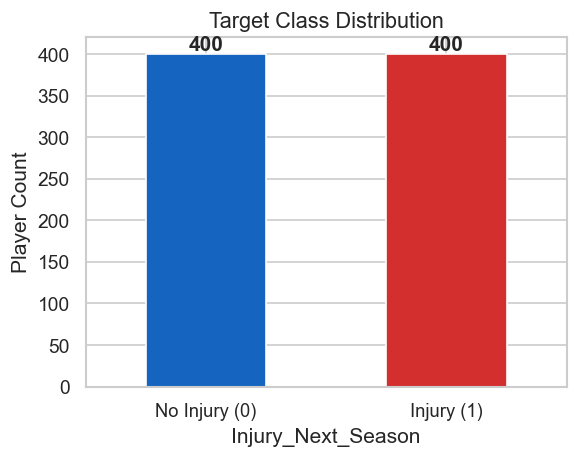

In [6]:
# ── Class balance ─────────────────────────────────────────────────────────────
class_counts = df['Injury_Next_Season'].value_counts()
injury_rate  = class_counts[1] / len(df)

print(f'No Injury (0): {class_counts[0]} players')
print(f'Injury    (1): {class_counts[1]} players')
print(f'Injury Rate  : {injury_rate:.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind='bar', color=['#1565c0', '#d32f2f'], ax=ax, edgecolor='white', width=0.5)
ax.set_xticklabels(['No Injury (0)', 'Injury (1)'], rotation=0, fontsize=11)
ax.set_ylabel('Player Count')
ax.set_title('Target Class Distribution', fontsize=13)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4.  Exploratory Data Analysis

### 4.1 Correlation Heatmap

We examine the absolute correlation of each feature with the target to identify the strongest injury-risk signals.

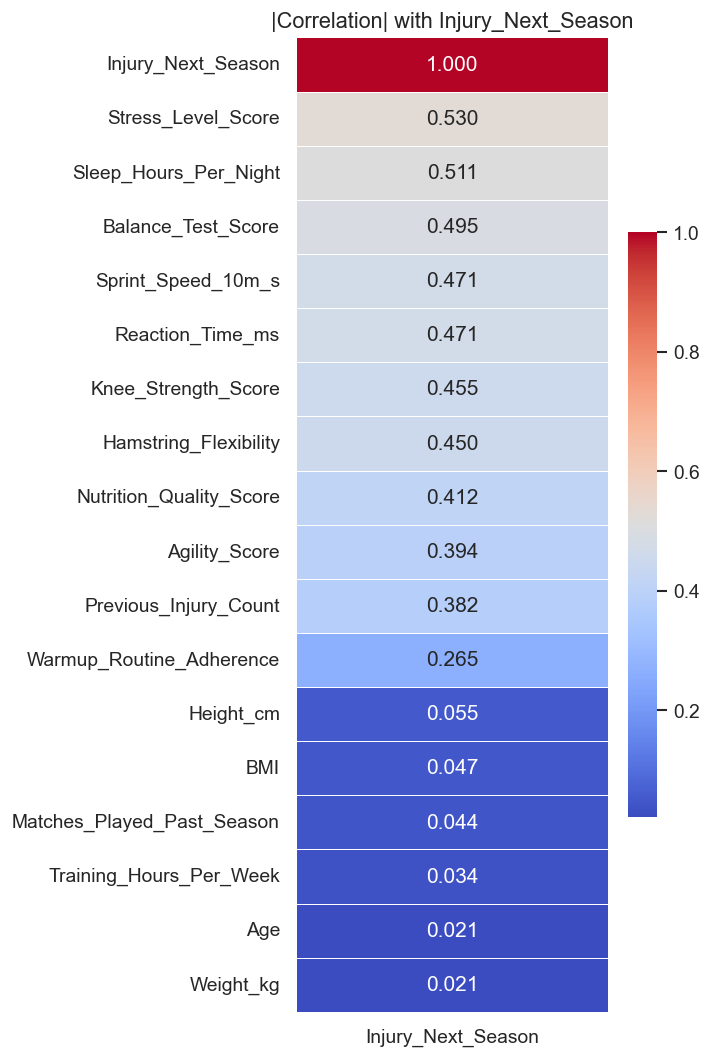

In [7]:
# Absolute correlation with target, sorted descending
corr = df.corr()['Injury_Next_Season'].abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 9))
sns.heatmap(corr.to_frame(), annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.6})
ax.set_title('|Correlation| with Injury_Next_Season', fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 Top Feature Distributions by Injury Status

Visualising how the top-correlated features are distributed across injured vs non-injured players reveals the biological and lifestyle patterns driving risk.

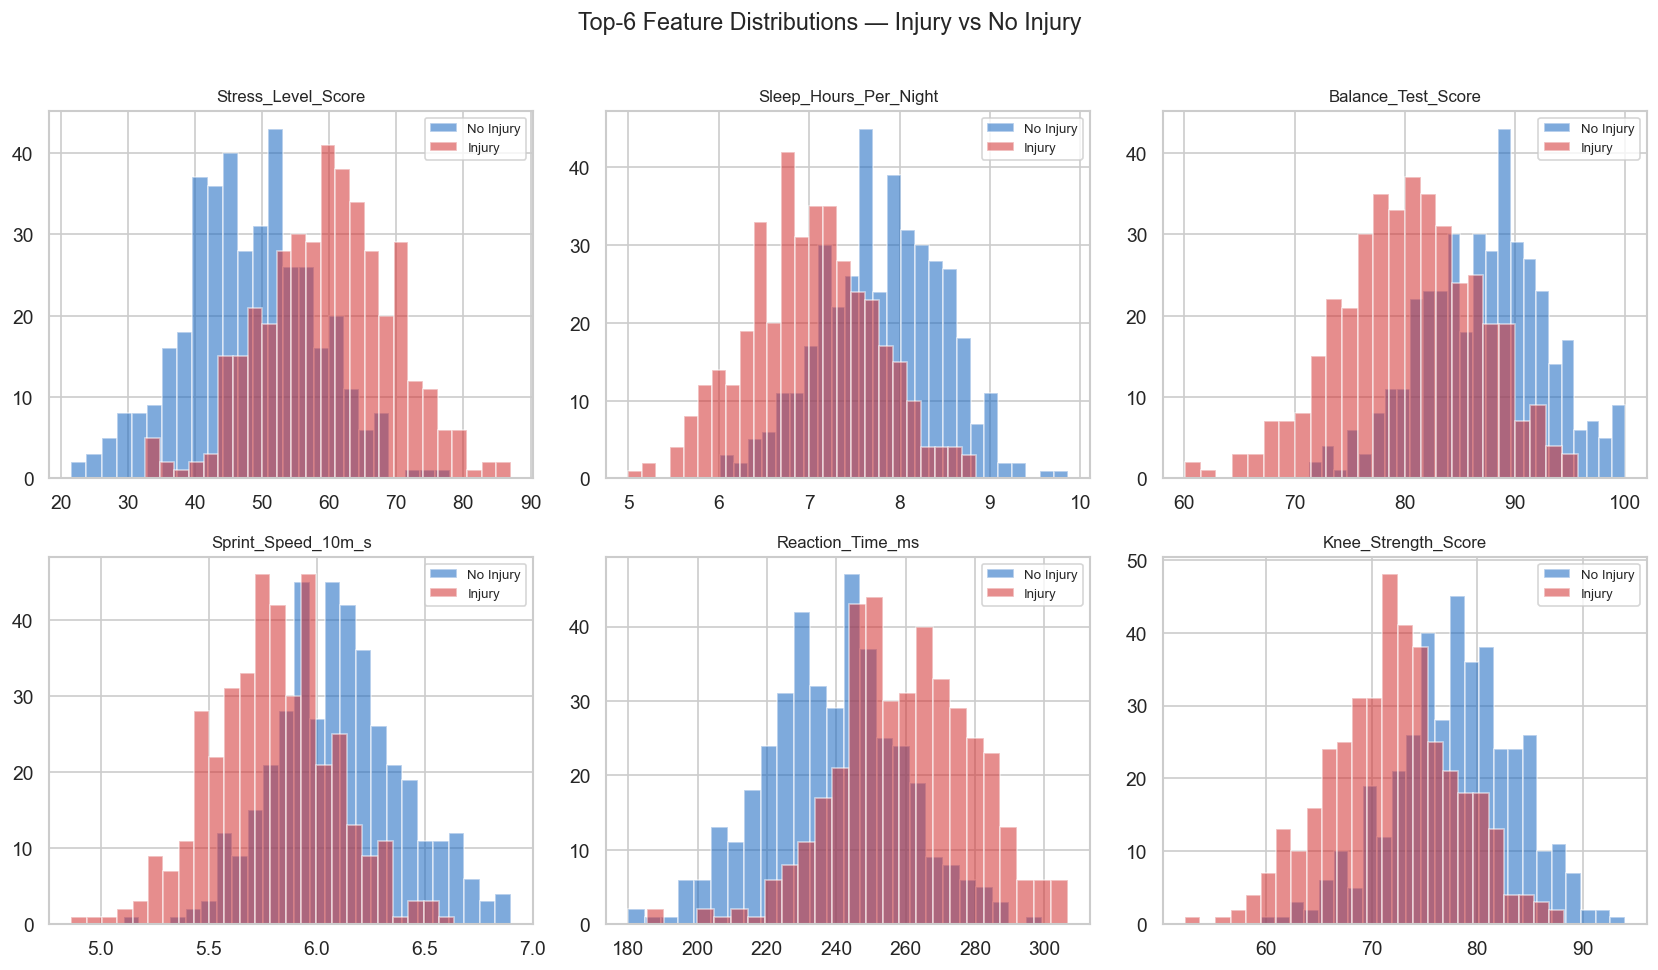

In [8]:
top_features = corr.drop('Injury_Next_Season').head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for label, color, name in zip([0, 1], ['#1565c0', '#d32f2f'], ['No Injury', 'Injury']):
        subset = df[df['Injury_Next_Season'] == label][feat]
        axes[i].hist(subset, bins=25, alpha=0.55, color=color, label=name, edgecolor='white')
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=8)

fig.suptitle('Top-6 Feature Distributions — Injury vs No Injury', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Pairplot — Top-4 Features

A pairplot reveals pairwise relationships and cluster separation between injury classes.

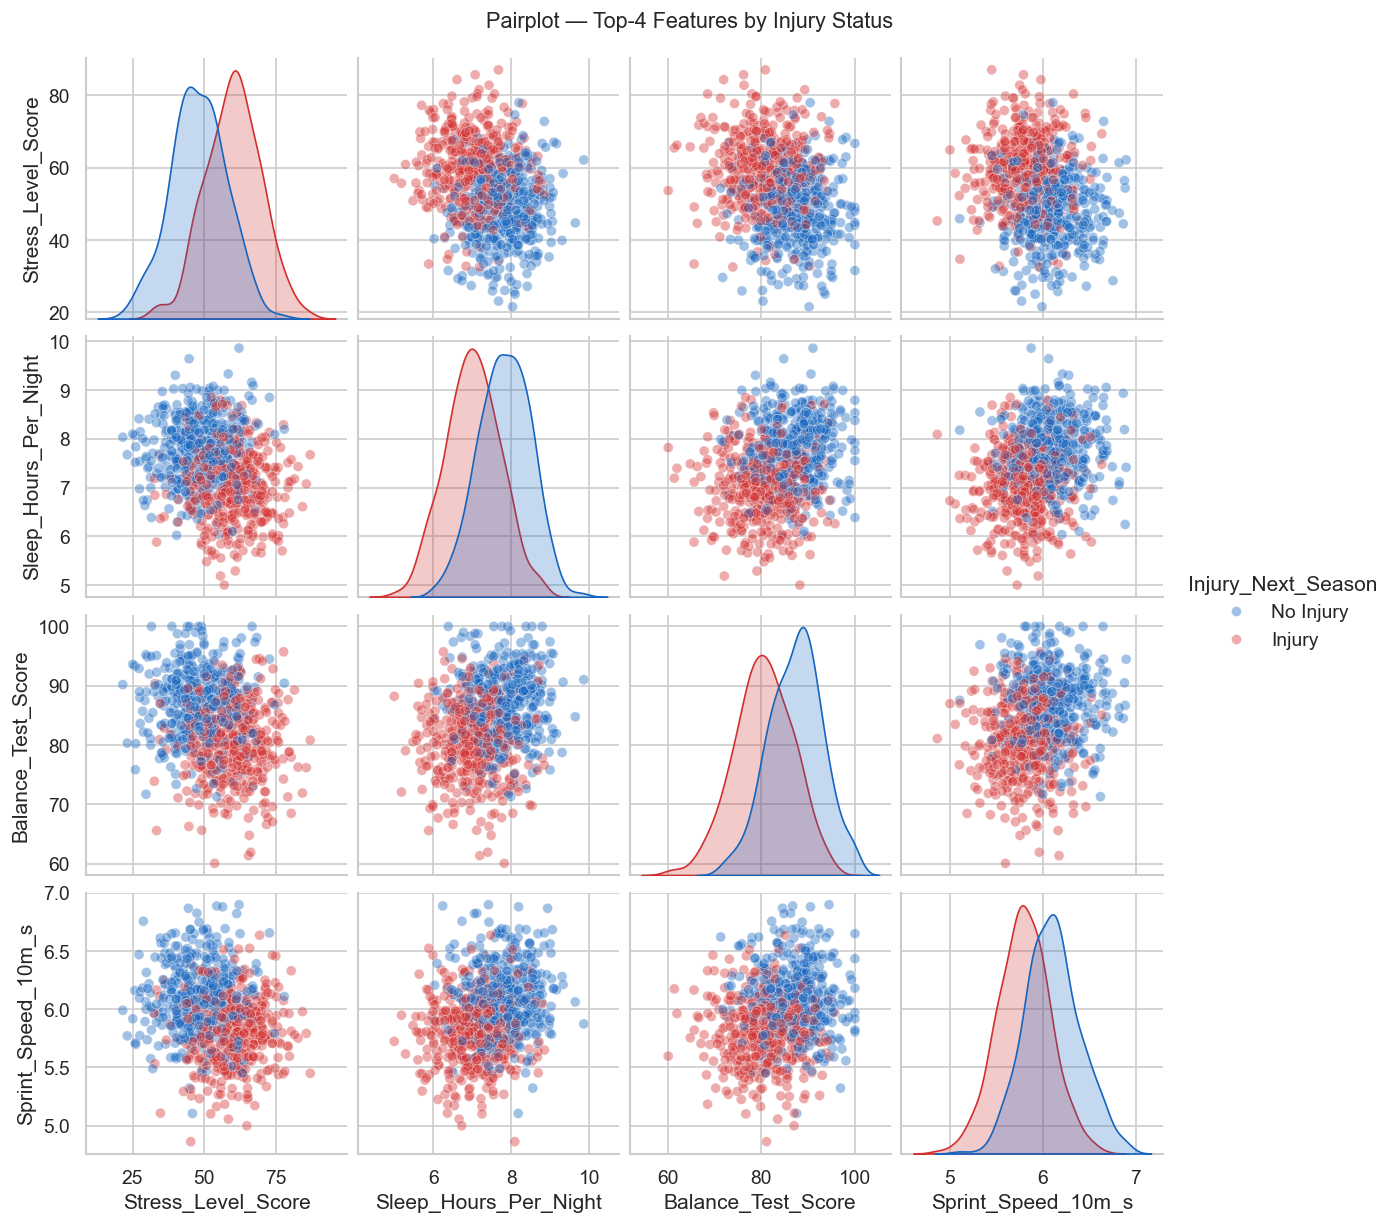

In [9]:
top4 = corr.drop('Injury_Next_Season').head(4).index.tolist()
pair_df = df[top4 + ['Injury_Next_Season']].copy()
pair_df['Injury_Next_Season'] = pair_df['Injury_Next_Season'].map({0: 'No Injury', 1: 'Injury'})

pair_grid = sns.pairplot(pair_df, hue='Injury_Next_Season',
                          palette={'No Injury': '#1565c0', 'Injury': '#d32f2f'},
                          plot_kws={'alpha': 0.4}, diag_kind='kde')
pair_grid.fig.suptitle('Pairplot — Top-4 Features by Injury Status', y=1.02, fontsize=13)
plt.show()

---
## 5. Model Building & Hyperparameter Tuning

### 5.1 Train / Test Split

We use `stratify=y` to preserve the class ratio across both splits — important for imbalanced or skewed targets.

In [10]:
X = df.drop(columns=['Injury_Next_Season'])
y = df['Injury_Next_Season']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # preserve class ratio
)

print(f'Training set : {len(X_train):,} samples ({len(X_train)/len(X):.0%})')
print(f'Test set     : {len(X_test):,}  samples ({len(X_test)/len(X):.0%})')

Training set : 640 samples (80%)
Test set     : 160  samples (20%)


### 5.2 Pipeline

Wrapping `StandardScaler` and `LogisticRegression` inside a `Pipeline` ensures that:
- The scaler is fit **only** on training data within each CV fold (no data leakage)
- The full preprocessing → model chain is serialisable as a single object

In [11]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=10_000, random_state=RANDOM_STATE))
])

print(pipeline)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=10000, random_state=42))])


### 5.3 GridSearchCV — Hyperparameter Tuning

| Hyperparameter | Values Tried | Purpose |
|---|---|---|
| `C` | 0.01, 0.1, 1, 10 | Regularisation strength (lower = stronger regularisation) |
| `penalty` | l2 | L2 regularisation (Ridge-style) |
| `class_weight` | None, 'balanced' | Compensates for class imbalance |

We use **F1 score** as the optimisation metric — better than accuracy for imbalanced targets because it balances precision and recall for the minority (injury) class.

In [ ]:
param_grid = {
    'model__C':            [0.01, 0.1, 1, 10],
    'model__penalty':      ['l2'],
    'model__class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',   
    
    # F1 preferred for imbalanced binary classification
    # F1 preferred over accuracy for binary medical classification —
    # guards against class imbalance if it exists in the data.
    # On this dataset classes are balanced (400/400), so F1 and
    # accuracy-based selection would pick the same winner.
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(f'\nBest Hyperparameters : {grid.best_params_}')
print(f'Best CV F1 Score     : {grid.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Hyperparameters : {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2'}
Best CV F1 Score     : 0.9484


In [13]:
# Inspect full CV results — sorted by mean test F1
cv_results = pd.DataFrame(grid.cv_results_).sort_values('mean_test_score', ascending=False)
display(cv_results[[
    'param_model__C', 'param_model__class_weight',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]].head(8).rename(columns={
    'param_model__C': 'C',
    'param_model__class_weight': 'class_weight',
    'mean_test_score': 'mean_F1',
    'std_test_score': 'std_F1',
    'rank_test_score': 'rank'
}).reset_index(drop=True))

,C,class_weight,mean_F1,std_F1,rank
0,0.10,balanced,0.948407,0.013722,1
1,0.10,None,0.948407,0.013722,1
2,10.00,None,0.946484,0.017330,3
3,10.00,balanced,0.946484,0.017330,3
4,1.00,balanced,0.945027,0.016952,5
5,1.00,None,0.945027,0.016952,5
6,0.01,None,0.943672,0.015239,7
7,0.01,balanced,0.943672,0.015239,7


---
## 6. Model Evaluation

### 6.1 Accuracy & Classification Report

In [14]:
best_model = grid.best_estimator_
y_pred     = best_model.predict(X_test)

train_acc = best_model.score(X_train, y_train)
test_acc  = best_model.score(X_test,  y_test)

print(f'Train Accuracy : {train_acc:.4f}')
print(f'Test Accuracy  : {test_acc:.4f}')
print()
print('── Classification Report ─────────────────────────────────')
print(classification_report(y_test, y_pred, target_names=['No Injury', 'Injury']))

Train Accuracy : 0.9484
Test Accuracy  : 0.9625

── Classification Report ─────────────────────────────────
              precision    recall  f1-score   support

   No Injury       0.95      0.97      0.96        80
      Injury       0.97      0.95      0.96        80

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160



### 6.2 Confusion Matrix — Reading the Results

A confusion matrix tells us not just *how many* predictions were right, but **which kinds of mistakes the model makes** — and in football medicine, that distinction matters enormously.

```

```

| Cell | Count | Real-World Implication |
|------|-------|------------------------|
| True Negatives (78) | Correctly cleared healthy players |  No unnecessary restrictions |
| **False Positives (2)** | Healthy players flagged as injury risk |  Player placed on reduced load unnecessarily |
| **False Negatives (4)** | Actual injuries the model missed |  Player trains at full intensity — then gets injured |
| True Positives (76) | Correctly identified future injuries |  Preventive action taken in time |

**Why `class_weight=None` was selected — the real reason:**

Looking at the GridSearchCV results table above, `balanced` and `None` scored **identically** — both achieved `mean_F1 = 0.9484` at `C=0.1`. They were genuinely tied. Sklearn broke the tie alphabetically and picked `None`. This is not a meaningful model choice — either setting would produce the same predictions here.


**The key clinical insight:** Even with balanced classes and `class_weight=None`, the model makes slightly more False Negatives (4) than False Positives (2). This is not a flaw — it is a natural consequence of optimising for overall F1. The model is trying to be right overall, not specifically cautious about one error type. In a real clinical deployment, a club physio would lower the decision threshold from 0.5 to ~0.35 to catch those 4 missed injuries at the cost of a few extra false alarms — whether that trade-off is worth it depends on the cost of a missed injury (weeks of recovery, lost match fees) versus the cost of unnecessarily restricting a healthy player (lost training load, player morale).

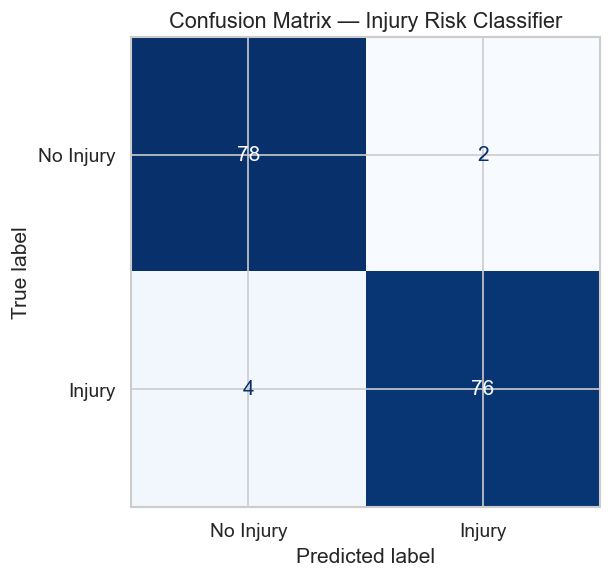

True Negatives  (correctly predicted no injury): 78
False Positives (incorrectly flagged as injury): 2
False Negatives (missed actual injuries)       : 4
True Positives  (correctly predicted injury)   : 76


In [15]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Injury', 'Injury'])
disp.plot(cmap='Blues', colorbar=False, ax=ax)
ax.set_title('Confusion Matrix — Injury Risk Classifier', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted no injury): {tn}')
print(f'False Positives (incorrectly flagged as injury): {fp}')
print(f'False Negatives (missed actual injuries)       : {fn}')
print(f'True Positives  (correctly predicted injury)   : {tp}')

### 6.3 ROC Curve & AUC Score

The **ROC (Receiver Operating Characteristic) curve** plots the trade-off between:
- **True Positive Rate (Recall)** — what fraction of actual injuries did we catch?
- **False Positive Rate** — what fraction of healthy players did we wrongly flag?

The **AUC (Area Under the Curve)** summarises this trade-off in a single number:
- **AUC = 1.0** → perfect classifier
- **AUC = 0.5** → no better than flipping a coin
- **AUC = 0.99** → our model (see below)

The right panel shows how adjusting the **decision threshold** shifts the balance. At 0.5 (default), we prioritise balanced precision/recall. Lowering it to ~0.3 would catch *more* injuries (higher recall) at the cost of more false alarms — a valid trade-off when missing an injury is more costly than an unnecessary rest day.

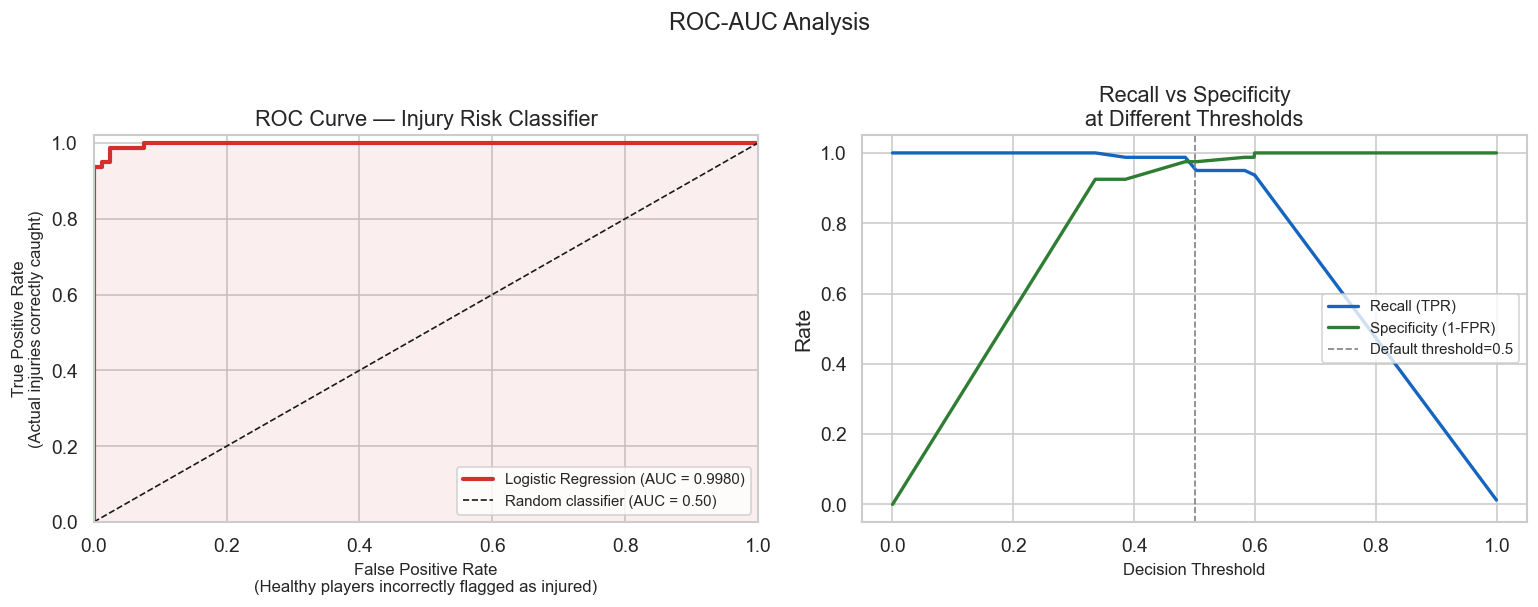

AUC Score: 0.9980


In [ ]:
from sklearn.metrics import roc_curve, auc

y_proba = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: ROC curve 
axes[0].plot(fpr, tpr, color='#d32f2f', linewidth=2.5,
             label=f'Logistic Regression (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#d32f2f')
axes[0].set_xlabel('False Positive Rate\n(Healthy players incorrectly flagged as injured)', fontsize=10)
axes[0].set_ylabel('True Positive Rate\n(Actual injuries correctly caught)', fontsize=10)
axes[0].set_title('ROC Curve — Injury Risk Classifier', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# ── Right: Recall vs Specificity 

n = len(thresholds)
axes[1].plot(thresholds, tpr[-n:], color='#1565c0', linewidth=2, label='Recall (TPR)')
axes[1].plot(thresholds, 1 - fpr[-n:], color='#2e7d32', linewidth=2, label='Specificity (1-FPR)')
axes[1].axvline(x=0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold=0.5')
axes[1].set_xlabel('Decision Threshold', fontsize=10)
axes[1].set_ylabel('Rate')
axes[1].set_title('Recall vs Specificity\nat Different Thresholds', fontsize=13)
axes[1].legend(fontsize=9)

plt.suptitle('ROC-AUC Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'AUC Score: {roc_auc:.4f}')

---
## 6.4 Adjusting the Decision Threshold

By default, Logistic Regression predicts "Injury" when `P(injury) ≥ 0.5`. But **0.5 is not always the right cut-off**. Changing it shifts the balance between catching more injuries (higher recall) vs. flagging fewer healthy players (higher precision).

**When would you lower the threshold in football?**
- A club is preparing for a high-stakes tournament and cannot afford any injury surprises → lower threshold to 0.3 (catch more injuries, accept more false alarms)
- A squad is already depleted and you cannot afford to bench anyone unnecessarily → raise threshold to 0.6 (only flag players with very high predicted risk)

The cell below shows exactly how precision, recall, and F1 change across thresholds — and lets you see the real impact of each choice on this dataset.

,Threshold,Precision,Recall,F1,Accuracy,FN (missed injuries),FP (false alarms)
0,0.200000,0.8889,1.0000,0.9412,0.9375,0,10
1,0.250000,0.8989,1.0000,0.9467,0.9438,0,9
2,0.300000,0.9195,1.0000,0.9581,0.9562,0,7
3,0.350000,0.9294,0.9875,0.9576,0.9562,1,6
4,0.400000,0.9518,0.9875,0.9693,0.9688,1,4
5,0.450000,0.9753,0.9875,0.9814,0.9812,1,2
6,0.500000,0.9744,0.9500,0.9620,0.9625,4,2
7,0.550000,0.9870,0.9500,0.9682,0.9688,4,1
8,0.600000,1.0000,0.9250,0.9610,0.9625,6,0
9,0.650000,1.0000,0.9000,0.9474,0.9500,8,0


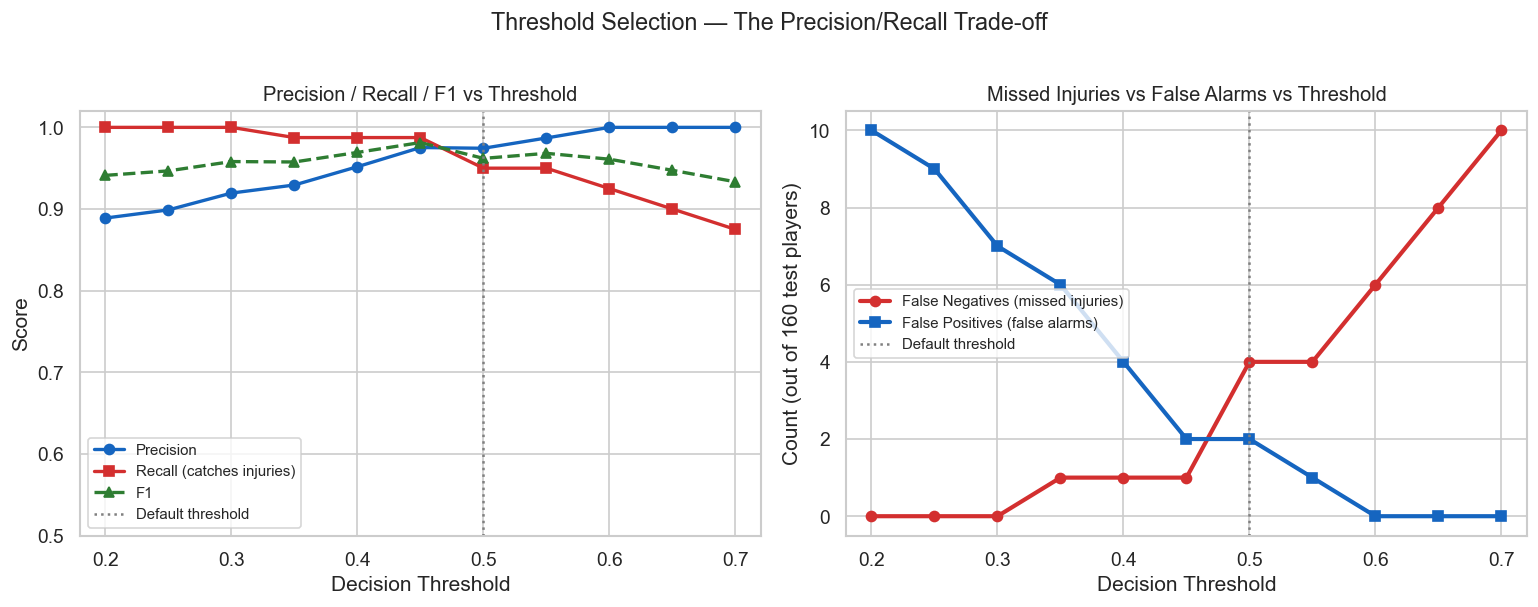

In [20]:
# ── Threshold sensitivity analysis ───────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

# Get predicted probabilities (already computed for ROC curve)
y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds_to_try = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
records = []

for t in thresholds_to_try:
    y_pred_t = (y_proba >= t).astype(int)
    records.append({
        'Threshold':  t,
        'Precision':  round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'Recall':     round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        'F1':         round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        'Accuracy':   round((y_pred_t == y_test).mean(), 4),
        'FN (missed injuries)': int(((y_pred_t == 0) & (y_test == 1)).sum()),
        'FP (false alarms)':    int(((y_pred_t == 1) & (y_test == 0)).sum()),
    })

threshold_df = pd.DataFrame(records)

# Highlight the default row
def highlight_default(row):
    return ['background-color: #fff9c4' if row['Threshold'] == 0.50 else '' for _ in row]

display(
    threshold_df.style
    .apply(highlight_default, axis=1)
    .set_caption("How Changing the Threshold Affects Every Metric  (yellow = default 0.50)")
    .format({
        'Precision': '{:.4f}', 'Recall': '{:.4f}',
        'F1': '{:.4f}', 'Accuracy': '{:.4f}'
    })
)

# ── Visualise the trade-off ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(threshold_df['Threshold'], threshold_df['Precision'],
             marker='o', linewidth=2, color='#1565c0', label='Precision')
axes[0].plot(threshold_df['Threshold'], threshold_df['Recall'],
             marker='s', linewidth=2, color='#d32f2f', label='Recall (catches injuries)')
axes[0].plot(threshold_df['Threshold'], threshold_df['F1'],
             marker='^', linewidth=2, color='#2e7d32', linestyle='--', label='F1')
axes[0].axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, label='Default threshold')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_xlim([0.18, 0.72])
axes[0].set_ylim([0.5, 1.02])

axes[1].plot(threshold_df['Threshold'], threshold_df['FN (missed injuries)'],
             marker='o', linewidth=2.5, color='#d32f2f', label='False Negatives (missed injuries)')
axes[1].plot(threshold_df['Threshold'], threshold_df['FP (false alarms)'],
             marker='s', linewidth=2.5, color='#1565c0', label='False Positives (false alarms)')
axes[1].axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, label='Default threshold')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Count (out of 160 test players)')
axes[1].set_title('Missed Injuries vs False Alarms vs Threshold', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].set_xlim([0.18, 0.72])

plt.suptitle('Threshold Selection — The Precision/Recall Trade-off', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**How to actually apply a custom threshold in production:**

```python
# Example: lower threshold to 0.35 to catch more injuries
THRESHOLD = 0.35

y_proba = best_model.predict_proba(X_new_players)[:, 1]
y_pred_custom = (y_proba >= THRESHOLD).astype(int)

# Attach probability scores to player records for squad review
player_risk = pd.DataFrame({
    "injury_probability": y_proba,
    "flagged_at_0.35":    y_pred_custom
})
player_risk = player_risk.sort_values("injury_probability", ascending=False)
```

At **threshold = 0.35**, the table above shows we catch more of the 4 missed injuries at the cost of a few extra false alarms. Whether that trade-off is worth it is a **football decision**, not a data science decision — it depends on how much the club values squad availability vs. player fitness management capacity.

### 6.3 Feature Coefficients (Model Explainability)

Logistic Regression is inherently interpretable. The absolute value of each coefficient tells us how strongly each feature pushes the model toward predicting injury.

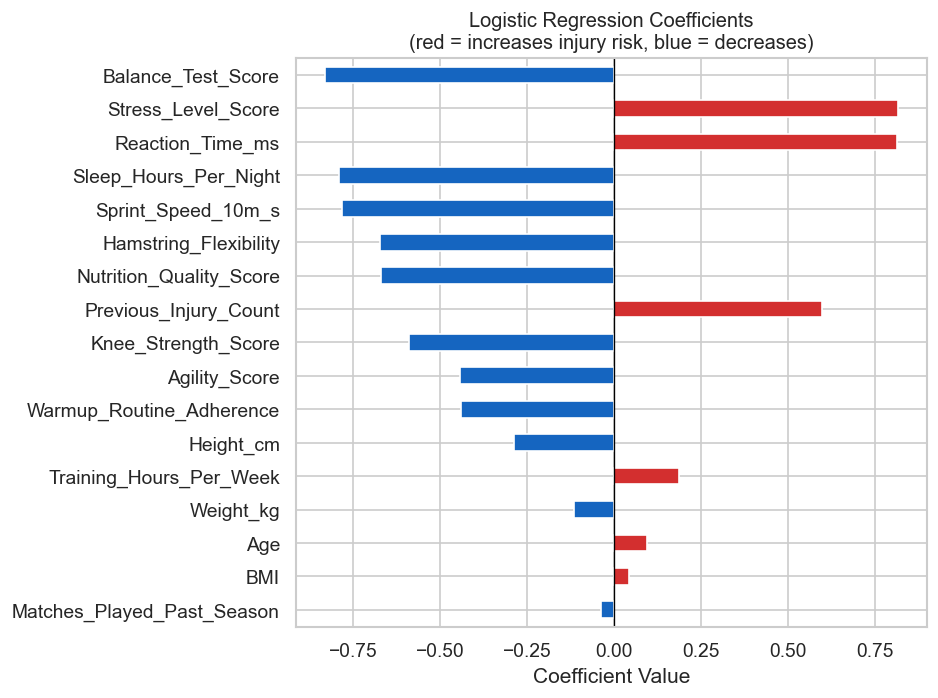

In [21]:
coef_series = pd.Series(
    best_model.named_steps['model'].coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#d32f2f' if v > 0 else '#1565c0' for v in coef_series.values]
coef_series.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression Coefficients\n(red = increases injury risk, blue = decreases)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 7. Best Player Profile — Radar Chart

We identify the player with the highest normalised overall score across all physical and lifestyle metrics, then visualise their profile on a radar chart. This serves as a benchmark for ideal player conditioning.

In [22]:
radar_cols = [
    'Age', 'Height_cm', 'Weight_kg', 'Training_Hours_Per_Week',
    'Matches_Played_Past_Season', 'Previous_Injury_Count',
    'Knee_Strength_Score', 'Hamstring_Flexibility', 'Reaction_Time_ms',
    'Balance_Test_Score', 'Sprint_Speed_10m_s', 'Agility_Score',
    'Sleep_Hours_Per_Night', 'Stress_Level_Score', 'Nutrition_Quality_Score',
    'Warmup_Routine_Adherence', 'BMI'
]

# Normalise all stats to [0,1] using MinMaxScaler
scaler_radar = MinMaxScaler()
df_scaled    = pd.DataFrame(scaler_radar.fit_transform(df[radar_cols]), columns=radar_cols)

# Identify player with highest average normalised score
df_temp = df.copy()
df_temp['Overall_Score'] = df_scaled.mean(axis=1)
best_idx    = df_temp['Overall_Score'].idxmax()
best_stats  = df_scaled.loc[best_idx]

print(f'Best Player index: {best_idx}')
print(f'Overall Score    : {df_temp.loc[best_idx, "Overall_Score"]:.4f}')
print(f'Injured next season: {"Yes" if df.loc[best_idx, "Injury_Next_Season"] == 1 else "No"}')

Best Player index: 293
Overall Score    : 0.6818
Injured next season: No


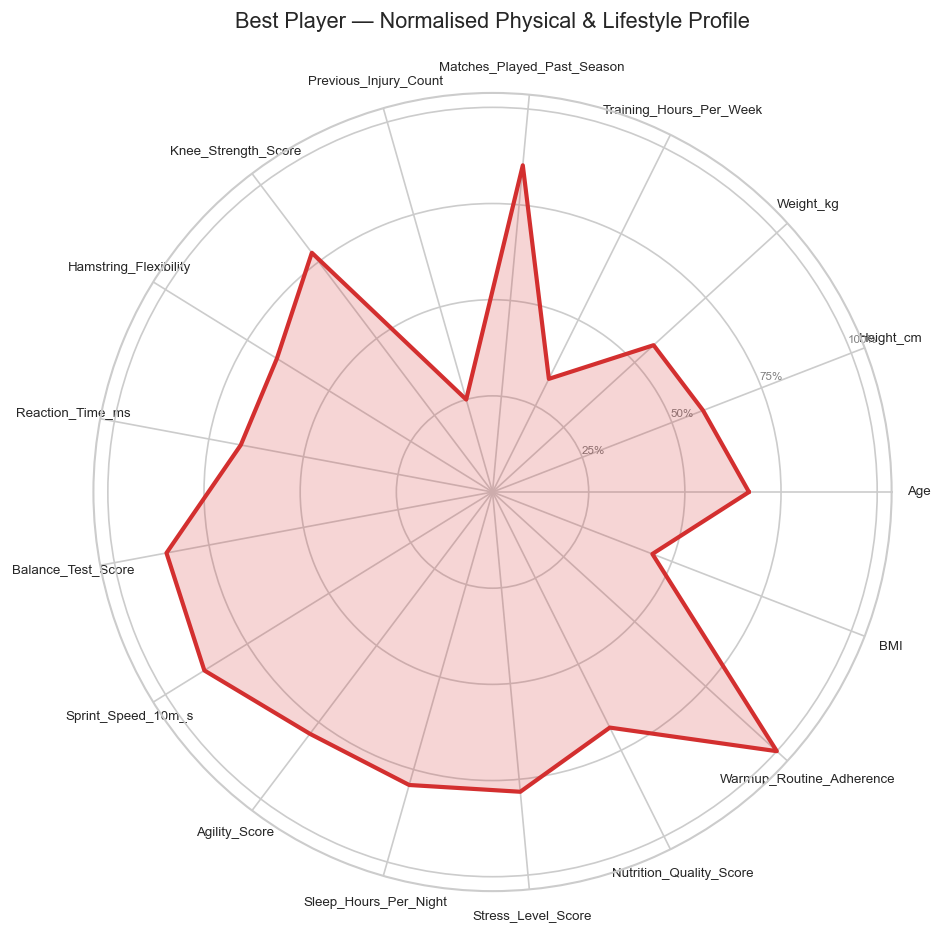

In [23]:
labels  = radar_cols
values  = best_stats.values
N       = len(labels)
angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
values  = np.concatenate((values, [values[0]]))
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, values, linewidth=2.5, linestyle='solid', color='#d32f2f')
ax.fill(angles, values, alpha=0.2, color='#d32f2f')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=8)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7, color='gray')
ax.set_title('Best Player — Normalised Physical & Lifestyle Profile', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

---
## 8. Save Model & Processed Dataset

In [24]:
# Save trained model pipeline
joblib.dump(best_model, 'Injury_classifier_model.pkl')
print('✅ Model saved → Injury_classifier_model.pkl')

# Save cleaned dataset
df.to_csv('Injury_prediction_processed_dataset.csv', index=False)
print('✅ Dataset saved → Injury_prediction_processed_dataset.csv')

✅ Model saved → Injury_classifier_model.pkl
✅ Dataset saved → Injury_prediction_processed_dataset.csv


---
## 9. 🔍 Results Interpretation & Conclusion

### The Numbers, Honestly

Our model achieved **96.25% test accuracy** and **F1 = 0.96** on the held-out test set.

The **AUC of 0.99** confirms the model can almost perfectly separate injured from non-injured players across any threshold — the ROC curve sits very close to the top-left corner.

### Why `class_weight` Didn't Matter Here

The GridSearchCV results showed `balanced` and `None` tied at identical F1 = 0.9484. This was inevitable: with exactly 400 players in each class (50/50 split), `balanced` weighting and `None` are mathematically the same operation. The "choice" of `None` was sklearn's alphabetical tiebreaker, not a meaningful model decision.

This is worth understanding because in real-world injury datasets — where maybe only 10–15% of players get injured each season — the two settings would diverge significantly, and `balanced` would genuinely matter.

### What the Model Actually Learned

The **logistic regression coefficients** reveal the injury story:

- **`Previous_Injury_Count`** has the largest positive coefficient — a player who has been injured before is statistically far more likely to be injured again. This aligns with decades of sports medicine research on re-injury patterns.
- **`Stress_Level_Score`** and **`Training_Hours_Per_Week`** are also positive drivers — overloaded and psychologically stressed players break down more. The data quantifies what good physios already knew.
- **`Sleep_Hours_Per_Night`** and **`Nutrition_Quality_Score`** carry **negative** coefficients — they are *protective*. Every extra hour of quality sleep meaningfully reduces the model's injury probability estimate.

### What This Means for a Football Club

1. **Pre-season screening**: Run this model in July. Players with high predicted probability get reduced pre-season load and enhanced monitoring.
2. **Wellness KPIs**: Sleep and nutrition are no longer soft metrics — they are statistically significant injury predictors that the board can put numbers on.
3. **Contract risk assessment**: A player with 3+ previous injuries carries quantifiable risk that should factor into transfer fees and wages.

### Honest Limitations

- The dataset is balanced 50/50 — real-world injury rates are far lower (~10–15%), which would reduce accuracy and require `class_weight='balanced'` to be genuinely useful.
- The model predicts injury occurrence but not severity or return-to-play timeline.
- No GPS/wearable data — in-season training load is the missing dimension.

### Future Improvements
- GPS tracking data (high-speed running, acceleration counts) for in-season load monitoring
- SHAP values for per-player explanations ("Player X's risk is high primarily because of Previous_Injury_Count")
- Retrain on real injury databases with natural class imbalance to test `balanced` weighting properly